## Beyond the Complaint Count: How Toronto 311 Service Requests Have Changed Over Time
Supervisor: Dr. Tamer Abdou

CIND820: Big Data Analytics Project

By: Kezia Mathew

## Milestone 3 Focus
This notebook builds on Milestone 2 by showing that the analysis pipeline runs from data loading to preprocessing, exploratory data analysis, and baseline model output. The project compares Toronto 311 customer-initiated service requests from 2010–2013 and 2022–2025.

The main goal at this stage is to produce initial results that show:
- whether the dataset loads and combines correctly;
- what data quality issues exist, including missing values and duplicate records;
- what the main univariate and bivariate patterns look like;
- how reported 311 demand differs between the early and recent periods;
- how one simple baseline model performs using a proper train/test setup.

The results are interpreted as patterns in reported 311 demand, not as proof of actual community need.

## Notebook Structure

This notebook is organized in the following order:

1. Import libraries and set file paths
2. Load the yearly Toronto 311 CSV files
3. Check the structure of each file
4. Combine the early and recent comparison periods
5. Create time-based variables such as year, month, weekday, and season
6. Complete data quality checks for missing values, duplicate rows, unique values, and date coverage
7. Complete univariate EDA for request type, division, status, year, month, and season
8. Complete bivariate EDA comparing early and recent periods
9. Build one simple baseline model for monthly request volume
10. Report model results and explain limitations, assumptions, and next steps

## Research Questions

The project is guided by three research questions:

####**Research Question 1:** How has reported 311 demand concentration by service request category and city division changed between 2010–2013 and 2022–2025?

####**Research Question 2:** Which high-volume 311 service request categories show different monthly or seasonal patterns between 2010–2013 and 2022–2025?

####**Research Question 3:** Which differences between the early and recent periods can be compared responsibly, and which require caution because of changes in categories, divisions, wards, data coverage, or reporting practices?

## Milestone 2 Feedback Addressed in Milestone 3

The main changes made for Milestone 3 are:

| Milestone 2 Feedback | How Milestone 3 Addresses It |
|---|---|
| Add actual univariate and bivariate EDA results | Added missingness tables, duplicate counts, distributions, period comparisons, charts, and cross-tabulations |
| Include exact missingness, duplicate counts, distributions, and period-based associations | Added data quality summary tables and early vs recent comparison outputs |
| Expand the methodological argument using at least six sources | The written report will connect the technical choices to the literature more clearly |
| Replace the arrow list with a labelled architecture diagram | The written report will include a labelled pipeline/architecture diagram with inputs, steps, and outputs |
| Remove unsupported optional modeling methods | NLP, Naive Bayes, regression, and cross-validation are not used as main methods because they do not fit the current dataset or project goal |
| Define evaluation criteria, assumptions, uncertainty checks, temporal controls, and leakage safeguards | Added a baseline model section with train/test split, metrics, assumptions, and leakage controls |
| Document dependencies, folder structure, execution order, file paths, and generated artifacts in GitHub | Added a reproducibility section and clearer notebook organization |
| Clarify GenAI tool, uses, verification process, and accountability | Added a coding assistance note explaining how AI was used and how outputs were checked |

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
DATA_PATH = "/content/drive/MyDrive/CIND 820/"

file_paths = {
    2010: DATA_PATH + "SR2010.csv",
    2011: DATA_PATH + "SR2011.csv",
    2012: DATA_PATH + "SR2012.csv",
    2013: DATA_PATH + "SR2013.csv",
    2022: DATA_PATH + "SR2022.csv",
    2023: DATA_PATH + "SR2023.csv",
    2024: DATA_PATH + "SR2024.csv",
    2025: DATA_PATH + "SR2025.csv"
}

file_paths

{2010: '/content/drive/MyDrive/CIND 820/SR2010.csv',
 2011: '/content/drive/MyDrive/CIND 820/SR2011.csv',
 2012: '/content/drive/MyDrive/CIND 820/SR2012.csv',
 2013: '/content/drive/MyDrive/CIND 820/SR2013.csv',
 2022: '/content/drive/MyDrive/CIND 820/SR2022.csv',
 2023: '/content/drive/MyDrive/CIND 820/SR2023.csv',
 2024: '/content/drive/MyDrive/CIND 820/SR2024.csv',
 2025: '/content/drive/MyDrive/CIND 820/SR2025.csv'}

In [67]:
df_2010 = pd.read_csv(file_paths[2010])

print("2010 file loaded successfully")
print("Shape:", df_2010.shape)

df_2010.head()

2010 file loaded successfully
Shape: (254218, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2010-01-01 00:38:26.0000000,Closed,Intersection,High Park Blvd,Parkside Dr,Parkdale-High Park (13),Road - Sanding / Salting Required,Transportation Services,Road Operations
1,2010-01-01 01:19:18.0000000,Closed,M4T,NaN,NaN,Toronto Centre-Rosedale (27),Water Service Line-Turn On,Toronto Water,District Ops
2,2010-01-01 01:19:48.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops
3,2010-01-01 01:24:18.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops
4,2010-01-01 01:42:26.0000000,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Watermain-Possible Break,Toronto Water,District Ops


In [68]:
df_2011 = pd.read_csv(file_paths[2011])

print("2011 file loaded successfully")
print("Shape:", df_2011.shape)

df_2011.head()

2011 file loaded successfully
Shape: (285333, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2011-01-01 01:04:36.0000000,Closed,M6S,NaN,NaN,Parkdale-High Park (13),Sewer Service Line-Blocked,Toronto Water,District Ops
1,2011-01-01 01:07:28.0000000,Closed,M1N,NaN,NaN,Scarborough Southwest (36),Noise,Municipal Licensing & Standards,District Enforcement
2,2011-01-01 03:19:14.0000000,Closed,M6S,NaN,NaN,Parkdale-High Park (13),Noise,Municipal Licensing & Standards,District Enforcement
3,2011-01-01 03:29:32.0000000,Closed,M1K,NaN,NaN,Scarborough Centre (37),Noise,Municipal Licensing & Standards,District Enforcement
4,2011-01-01 07:40:32.0000000,Closed,M4J,NaN,NaN,Toronto-Danforth (29),Residential: Garbage Bin: Exchange to Small,Solid Waste Management Services,Collections


In [69]:
df_2012 = pd.read_csv(file_paths[2012])

print("2012 file loaded successfully")
print("Shape:", df_2012.shape)

df_2012.head()

2012 file loaded successfully
Shape: (307299, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2012-01-01 00:08:09.0000000,Closed,M6L,NaN,NaN,York South-Weston (12),Hydrant-Damage,Toronto Water,District Ops
1,2012-01-01 00:30:41.0000000,Closed,M1E,NaN,NaN,Scarborough East (43),Permit Inspection,Urban Forestry,Tree Protection and Plan Review
2,2012-01-01 00:36:36.0000000,Closed,M1W,NaN,NaN,Scarborough-Agincourt (40),Publication Request - Transportation,311,Operations
3,2012-01-01 01:27:55.0000000,Closed,M2J,NaN,NaN,Don Valley East (33),Property Standards,Municipal Licensing & Standards,District Enforcement
4,2012-01-01 02:31:02.0000000,Closed,M2N,NaN,NaN,Willowdale (24),Residential Furniture / Not Picked Up,Solid Waste Management Services,Collections


In [70]:
df_2013 = pd.read_csv(file_paths[2013])

print("2013 file loaded successfully")
print("Shape:", df_2013.shape)

df_2013.head()

2013 file loaded successfully
Shape: (385870, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2013-01-01 00:28:37.0000000,Closed,M1B,NaN,NaN,Scarborough-Rouge River (42),Sidewalk - Cleaning,Transportation Services,Road Operations
1,2013-01-01 00:44:18.0000000,Closed,M4K,NaN,NaN,Toronto-Danforth (29),Sidewalk Icy|| Needs Sand/Salt,Transportation Services,Road Operations
2,2013-01-01 01:04:28.0000000,Closed,M6M,NaN,NaN,York South-Weston (12),STRAY AT LARGE,Municipal Licensing & Standards,Toronto Animal Services
3,2013-01-01 01:12:13.0000000,Closed,M2R,NaN,NaN,Willowdale (23),Noise,Municipal Licensing & Standards,District Enforcement
4,2013-01-01 02:12:10.0000000,Closed,M9C,NaN,NaN,Etobicoke Centre (03),Boulevard - Plough Damage,Transportation Services,Road Operations


In [71]:
# The 2022 file has one line w/ formatting issues
# Expected 9 fields in line 117, saw 10
# skipping that row so we can load data

df_2022 = pd.read_csv(file_paths[2022], on_bad_lines="skip")

print("2022 file loaded successfully")
print("Shape:", df_2022.shape)

df_2022.head()

2022 file loaded successfully
Shape: (427903, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2022-01-01 00:12:24.0000000,Completed,M1E,NaN,NaN,Scarborough-Rouge Park (25),Fireworks,Municipal Licensing & Standards,Parks Enforcement
1,2022-01-01 00:20:34.0000000,Completed,M9N,NaN,NaN,York South-Weston (05),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
2,2022-01-01 00:31:00.0000000,Completed,M3J,NaN,NaN,York Centre (06),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
3,2022-01-01 00:31:28.0000000,Completed,M3H,NaN,NaN,York Centre (06),Fireworks,Municipal Licensing & Standards,Parks Enforcement
4,2022-01-01 00:37:50.0000000,Completed,M9C,NaN,NaN,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement


In [72]:
# similar to issue above, Expected 9 fields in line 19, saw 10

df_2023 = pd.read_csv(file_paths[2023], on_bad_lines="skip")

print("2023 file loaded successfully")
print("Shape:", df_2023.shape)

df_2023.head()

2023 file loaded successfully
Shape: (385975, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2023-01-01 00:10:38.0000000,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),Sewer Service Line-Blocked,Toronto Water,District Ops
1,2023-01-01 00:31:00.0000000,Completed,M6K,NaN,NaN,Parkdale-High Park (04),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
2,2023-01-01 00:32:11.0000000,Completed,M3N,NaN,NaN,Humber River-Black Creek (07),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
3,2023-01-01 00:42:35.0000000,Completed,M9N,NaN,NaN,York South-Weston (05),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
4,2023-01-01 00:49:51.0000000,Completed,M4S,NaN,NaN,Toronto-St. Paul's (12),Unreasonable and Persistent Noise,Municipal Licensing & Standards,Bylaw Enforcement


In [73]:
#Expected 9 fields in line 89, saw 10, skipping that roq

df_2024 = pd.read_csv(file_paths[2024], on_bad_lines="skip")

print("2024 file loaded successfully")
print("Shape:", df_2024.shape)

df_2024.head()

2024 file loaded successfully
Shape: (402824, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2024-01-01 00:10:57.0000000,Completed,M4A,NaN,NaN,Beaches-East York (19),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
1,2024-01-01 00:20:03.0000000,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),Fireworks,Municipal Licensing & Standards,Parks Enforcement
2,2024-01-01 00:29:48.0000000,Unknown,M6C,NaN,NaN,Toronto-St. Paul's (12),Business Complaint,Municipal Licensing & Standards,Business Licensing Enforcement
3,2024-01-01 00:37:32.0000000,Unknown,M1R,NaN,NaN,Scarborough Centre (21),Unknown - MLSBLEMMVN,Unknown,Unknown
4,2024-01-01 00:52:35.0000000,Completed,M3M,NaN,NaN,York Centre (06),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement


In [74]:
# The 2025 file has an encoding issue, so I used latin1 encoding to load it.

df_2025 = pd.read_csv(file_paths[2025], encoding="latin1", on_bad_lines="skip")

print("2025 file loaded successfully")
print("Shape:", df_2025.shape)

df_2025.head()

2025 file loaded successfully
Shape: (464080, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2025-01-01 00:01:05.0000000,Completed,M8Y,NaN,NaN,Etobicoke-Lakeshore (03),Injured - Domestic,Municipal Licensing & Standards,Toronto Animal Services
1,2025-01-01 00:02:16.0000000,Completed,M5V,NaN,NaN,Spadina-Fort York (10),Amplified Sound or Instrument Sound,Municipal Licensing & Standards,Bylaw Enforcement
2,2025-01-01 00:14:46.0000000,Cancelled,M1V,NaN,NaN,Scarborough North (23),Zoning Regulations Violations,Municipal Licensing & Standards,Investigation Services
3,2025-01-01 00:16:28.0000000,Completed,M1V,NaN,NaN,Scarborough North (23),Illegal Off-Street Parking,Transportation Services,Right of Way (ROW)
4,2025-01-01 00:25:00.0000000,Completed,M9R,NaN,NaN,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement


In [75]:
df_2010["Source Year"] = 2010
df_2011["Source Year"] = 2011
df_2012["Source Year"] = 2012
df_2013["Source Year"] = 2013

df_2022["Source Year"] = 2022
df_2023["Source Year"] = 2023
df_2024["Source Year"] = 2024
df_2025["Source Year"] = 2025

In [76]:
df_2025.head() #source year is coumn 10

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,Source Year
0,2025-01-01 00:01:05.0000000,Completed,M8Y,NaN,NaN,Etobicoke-Lakeshore (03),Injured - Domestic,Municipal Licensing & Standards,Toronto Animal Services,2025
1,2025-01-01 00:02:16.0000000,Completed,M5V,NaN,NaN,Spadina-Fort York (10),Amplified Sound or Instrument Sound,Municipal Licensing & Standards,Bylaw Enforcement,2025
2,2025-01-01 00:14:46.0000000,Cancelled,M1V,NaN,NaN,Scarborough North (23),Zoning Regulations Violations,Municipal Licensing & Standards,Investigation Services,2025
3,2025-01-01 00:16:28.0000000,Completed,M1V,NaN,NaN,Scarborough North (23),Illegal Off-Street Parking,Transportation Services,Right of Way (ROW),2025
4,2025-01-01 00:25:00.0000000,Completed,M9R,NaN,NaN,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement,2025


In [77]:
# The years combined into one dataframe

df = pd.concat(
    [df_2010, df_2011, df_2012, df_2013, df_2022, df_2023, df_2024, df_2025],
    ignore_index=True # combining all rows w/out repeatin row numbers, new row index
)

print("Combined dataframe created successfully.")
print("Shape:", df.shape)

df.head()

Combined dataframe created successfully.
Shape: (2913502, 10)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,Source Year
0,2010-01-01 00:38:26.0000000,Closed,Intersection,High Park Blvd,Parkside Dr,Parkdale-High Park (13),Road - Sanding / Salting Required,Transportation Services,Road Operations,2010
1,2010-01-01 01:19:18.0000000,Closed,M4T,NaN,NaN,Toronto Centre-Rosedale (27),Water Service Line-Turn On,Toronto Water,District Ops,2010
2,2010-01-01 01:19:48.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops,2010
3,2010-01-01 01:24:18.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops,2010
4,2010-01-01 01:42:26.0000000,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Watermain-Possible Break,Toronto Water,District Ops,2010


In [78]:
# Early vs REcent Period

df["Period"] = np.where(
    df["Source Year"].isin([2010, 2011, 2012, 2013]),
    "Early Period (2010-2013)",
    "Recent Period (2022-2025)"
)

df[["Source Year", "Period"]].head()

,Source Year,Period
0,2010,Early Period (2010-2013)
1,2010,Early Period (2010-2013)
2,2010,Early Period (2010-2013)
3,2010,Early Period (2010-2013)
4,2010,Early Period (2010-2013)


In [79]:
# number of rows in each period

df["Period"].value_counts()

,count
Period,
Recent Period (2022-2025),1680782
Early Period (2010-2013),1232720


##### The dataset total of both early and recent periods contain 2,913,502 records. The early period from 2010–2013 contains 1,232,720 records, while the recent period from 2022–2025 contains 1,680,782 records. This shows that the recent period has a higher number of reported 311 service requests. However, this should be interpreted as reported demand only, not as proof that actual municipal service need increased.

In [80]:
# rows in each source year

df["Source Year"].value_counts().sort_index()

,count
Source Year,
2010,254218
2011,285333
2012,307299
2013,385870
2022,427903
2023,385975
2024,402824
2025,464080


##### The combined dataset includes eight full years of Toronto 311 customer-initiated service request data. The number of records generally increases across the early years, from 254,218 records in 2010 to 385,870 records in 2013. In the recent period, 2025 has the highest number of records with 464,080 requests. These counts help show the size of each yearly file before moving into missing value checks, date cleaning, and exploratory analysis.

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2913502 entries, 0 to 2913501
Data columns (total 11 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Creation Date                 object
 1   Status                        object
 2   First 3 Chars of Postal Code  object
 3   Intersection Street 1         object
 4   Intersection Street 2         object
 5   Ward                          object
 6   Service Request Type          object
 7   Division                      object
 8   Section                       object
 9   Source Year                   int64 
 10  Period                        object
dtypes: int64(1), object(10)
memory usage: 244.5+ MB


In [82]:
# need to make creation date to datetime format
df["Creation Date"] = pd.to_datetime(df["Creation Date"], errors="coerce")

In [83]:
df["Creation Date"].dtype

dtype('<M8[ns]')

##### The Creation Date column was originally read as an object, which means Python treated it as text. I converted it to datetime format so that I can create time-based variables such as year, month, weekday, and season. I used "errors=coerce" so that any date values that could not be converted would become missing values instead of stopping the notebook. I used Chatgpt to help me figure out how to convert the missing values by showing it the steps I had already taken and what I needed. I'm asking panda to not crash if it finds a value it cannot convert. Instead turn it into a missing date value.

In [84]:
df["Creation Date"].isna().sum()

np.int64(0)

#### After converting the Creation Date column to datetime format, there were 0 missing date values. This means all Creation Date values were successfully converted and can be used to create year, month, weekday, and season variables.

In [85]:
# want to pull out the specific, month, year, period, etc...

df["Year"] = df["Creation Date"].dt.year
df["Month"] = df["Creation Date"].dt.month
df["Month Name"] = df["Creation Date"].dt.month_name()
df["Weekday"] = df["Creation Date"].dt.day_name()

df[["Creation Date", "Year", "Month", "Month Name", "Weekday", "Source Year", "Period"]].head()

,Creation Date,Year,Month,Month Name,Weekday,Source Year,Period
0,2010-01-01 00:38:26,2010,1,January,Friday,2010,Early Period (2010-2013)
1,2010-01-01 01:19:18,2010,1,January,Friday,2010,Early Period (2010-2013)
2,2010-01-01 01:19:48,2010,1,January,Friday,2010,Early Period (2010-2013)
3,2010-01-01 01:24:18,2010,1,January,Friday,2010,Early Period (2010-2013)
4,2010-01-01 01:42:26,2010,1,January,Friday,2010,Early Period (2010-2013)


In [86]:
# Checking to make sure the year from Creation date does infact match the Source Year
# 2,913,502 is the total number of rows from all periods, so there's notne that do not match!
df["Year Match"] = df["Year"] == df["Source Year"]
df["Year Match"].value_counts()

,count
Year Match,
True,2913502


In [87]:
# Seasons by month count

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)

df[["Creation Date", "Month", "Month Name", "Season"]].head()

,Creation Date,Month,Month Name,Season
0,2010-01-01 00:38:26,1,January,Winter
1,2010-01-01 01:19:18,1,January,Winter
2,2010-01-01 01:19:48,1,January,Winter
3,2010-01-01 01:24:18,1,January,Winter
4,2010-01-01 01:42:26,1,January,Winter


In [88]:
df["Season"].value_counts()

,count
Season,
Summer,837429
Fall,718419
Spring,704238
Winter,653416


The Season column was created from the Month column. Winter includes December, January, and February; Spring includes March, April, and May; Summer includes June, July, and august; and Fall includes September, October, and November. This variable is needed for the seasonal part of the analysis because RQ2 compares monthly and seasonal patterns between the early and recent periods.

In [89]:
#ordering them differently

df["Season"].value_counts().reindex(["Spring", "Summer", "Fall", "Winter"])

,count
Season,
Spring,704238
Summer,837429
Fall,718419
Winter,653416


##### Summer has the highest number of reported 311 service requests with 837,429 records, followed by Fall with 718,419 records, Spring with 704,238 records, and lastly Winter with 653,416 records. This gives an early indication that reported 311 activity is not evenly distributed across seasons, which connects to RQ2 on monthly and seasonal patterns.

In [90]:
df.isna().sum()

,0
Creation Date,0
Status,0
First 3 Chars of Postal Code,0
Intersection Street 1,2549187
Intersection Street 2,2551174
Ward,0
Service Request Type,0
Division,0
Section,0
Source Year,0


##### The missing value check showed that most fields used in the main analysis have 0 missing values, including Creation Date, Status, Ward, Service Request Type, Division, Section, Source Year, Period, Year, Month, Month Name, Weekday, and Season. The main missingness issue is with the two intersection street fields. Intersection Street 1 has 2,549,187 missing values and Intersection Street 2 has 2,551,174 missing values. Because these fields are not central to the main research questions, they will not be used as primary analysis variables. This supports the decision to focus on service request type, division, time period, month, season, and status instead.

In [91]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percent": (df.isna().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Count,Missing Percent
Creation Date,0,0.00
Status,0,0.00
First 3 Chars of Postal Code,0,0.00
Intersection Street 1,2549187,87.50
Intersection Street 2,2551174,87.56
Ward,0,0.00
Service Request Type,0,0.00
Division,0,0.00
Section,0,0.00
Source Year,0,0.00


intersection street names being missing makes sense. THis is for privacy and safety issues to the civillians entering reports, to protect their identity.

In [92]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

2318


In [93]:
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows.shape[0])
duplicate_rows.head(10)

3810


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,Source Year,Period,Year,Month,Month Name,Weekday,Year Match,Season
657,2010-01-04 10:01:54,Closed,M4J,NaN,NaN,Toronto-Danforth (29),All / White Goods / Pick Up Request,Solid Waste Management Services,Collections,2010,Early Period (2010-2013),2010,1,January,Monday,True,Winter
658,2010-01-04 10:01:54,Closed,M4J,NaN,NaN,Toronto-Danforth (29),All / White Goods / Pick Up Request,Solid Waste Management Services,Collections,2010,Early Period (2010-2013),2010,1,January,Monday,True,Winter
47008,2010-03-30 11:33:40,Closed,M5P,NaN,NaN,St. Paul's (21),Water Service Line-No Water,Toronto Water,District Ops,2010,Early Period (2010-2013),2010,3,March,Tuesday,True,Spring
47009,2010-03-30 11:33:40,Closed,M5P,NaN,NaN,St. Paul's (21),Water Service Line-No Water,Toronto Water,District Ops,2010,Early Period (2010-2013),2010,3,March,Tuesday,True,Spring
75243,2010-05-12 08:31:40,Cancelled,Intersection,Dufferin St,College St,Davenport (18),Traffic Signal Maintenance,Transportation Services,TMC,2010,Early Period (2010-2013),2010,5,May,Wednesday,True,Spring
75244,2010-05-12 08:31:40,Cancelled,Intersection,Dufferin St,College St,Davenport (18),Traffic Signal Maintenance,Transportation Services,TMC,2010,Early Period (2010-2013),2010,5,May,Wednesday,True,Spring
370321,2011-06-08 21:28:52,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Storm Clean Up,Urban Forestry,Forestry Operations,2011,Early Period (2010-2013),2011,6,June,Wednesday,True,Summer
370322,2011-06-08 21:28:52,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Storm Clean Up,Urban Forestry,Forestry Operations,2011,Early Period (2010-2013),2011,6,June,Wednesday,True,Summer
387911,2011-06-28 16:01:02,Closed,M1B,NaN,NaN,Scarborough-Rouge River (42),Residential Furniture / Not Picked Up,Solid Waste Management Services,Collections,2011,Early Period (2010-2013),2011,6,June,Tuesday,True,Summer
387912,2011-06-28 16:01:02,Closed,M1B,NaN,NaN,Scarborough-Rouge River (42),Residential Furniture / Not Picked Up,Solid Waste Management Services,Collections,2011,Early Period (2010-2013),2011,6,June,Tuesday,True,Summer


###### The duplicate check found 2,318 extra duplicate rows in the combined dataset. When all rows involved in duplicate groups were displayed, including both the original records and repeated records, 3,810 rows were seen. I cannot fully confirm whether every duplicate is a true data issue or a repeated report with identical information. The duplicate count is very small compared to the full dataset of 2,913,502 records, so it it will only slightly affect request counts, rankings, and percentage shares.

In [94]:
duplicate_percent = (duplicate_count / len(df)) * 100
print("Duplicate percentage:", round(duplicate_percent, 2), "%")

Duplicate percentage: 0.08 %


#### The combined dataset has 2,318 extra duplicate rows, which represents 0.08% of the full dataset.

In [95]:
# unique values in each columns

unique_counts = df[
    [
        "Status",
        "First 3 Chars of Postal Code",
        "Ward",
        "Service Request Type",
        "Division",
        "Section",
        "Source Year",
        "Period",
        "Month Name",
        "Weekday",
        "Season"
    ]
].nunique().sort_values(ascending=False)

unique_counts

#to things to note,
#1. 970 different service request types across Toronto that are or were being used
#2. thre are 69

,0
Service Request Type,970
First 3 Chars of Postal Code,101
Ward,69
Section,29
Month Name,12
Division,10
Status,9
Source Year,8
Weekday,7
Season,4


###### There are 970 unique Service Request Type values, meaning caution is needed. It also supports why I should focus on top categories, rankings, percentage shares, and period comparisons instead of trying to interpret every single request type. As well, there are 69 unique Ward values across the combined dataset. This makes sense because the early and recent periods use different ward structures. This will supports my decision to treat ward-level comparisons cautiously.

In [96]:
print("Earliest date:", df["Creation Date"].min())
print("Latest date:", df["Creation Date"].max())

#so the full data range is from January 1 2010 to December 31, 2025
# excluding data from Jan 1, 2014 to Dec 31, 2021

Earliest date: 2010-01-01 00:38:26
Latest date: 2025-12-31 23:59:32


In [97]:
date_range_by_period = df.groupby("Period")["Creation Date"].agg(["min", "max"])
date_range_by_period

# Jan 1, 2010 to Dec 31, 2013
# Jan 1, 2022 to Dec 31, 2025

,min,max
Period,,
Early Period (2010-2013),2010-01-01 00:38:26,2013-12-31 23:24:39
Recent Period (2022-2025),2022-01-01 00:12:24,2025-12-31 23:59:32


### Exploratory Data Analysis

In [98]:
status_counts = df["Status"].value_counts()
status_counts

,count
Status,
Completed,1322048
Closed,1184993
Cancelled,267053
In Progress,62243
New,41158
Unknown,23386
Initiated,8430
In-progress,4107
In-Progress,84


#### Status Distribution Results

##### The Status distribution shows that most records are marked as Completed or Closed. Completed has 1,322,048 records, while Closed has 1,184,993 records. Cancelled is the next largest status category with 267,053 records. The remaining status categories are much smaller. This check also showed a minor formatting issue in the Status field because there are three "in progress" columns just written differently. In Progress, In-progress, and In-Progress appear as separate values. These likely refer to the same general status but are treated as separate categories because of differences in capitalization and punctuation. Since Status is not the main focus of the research questions, I documented this as a data quality issue instead of making it a main analysis variable.

In [99]:
status_summary = pd.DataFrame({
    "Count": df["Status"].value_counts(),
    "Percent": (df["Status"].value_counts() / len(df) * 100).round(2)
})

status_summary

#largest category is Completed at 45.38%, followed by Closed at 40.57%, and then Cancelled at 9.17%

,Count,Percent
Status,,
Completed,1322048,45.38
Closed,1184993,40.67
Cancelled,267053,9.17
In Progress,62243,2.14
New,41158,1.41
Unknown,23386,0.80
Initiated,8430,0.29
In-progress,4107,0.14
In-Progress,84,0.00


In [100]:
# Service Types: Top 15

top_service_types = df["Service Request Type"].value_counts().head(15)
top_service_types

,count
Service Request Type,
Property Standards,94487
Residential Furniture / Not Picked Up,83812
Sewer Service Line-Blocked,71653
Res / Garbage / Not Picked Up,66825
Injured - Wildlife,64628
Residential: Bin: Repair or Replace Lid,62759
Res / Recycle / Not Picked Up,57951
Res / Organic Green Bin / Not Picked Up,57450
Road - Pot hole,53816


In [101]:
# Service Type by percentage

top_service_summary = pd.DataFrame({
    "Count": df["Service Request Type"].value_counts().head(15),
    "Percent": (df["Service Request Type"].value_counts().head(15) / len(df) * 100).round(2)
})

top_service_summary

,Count,Percent
Service Request Type,,
Property Standards,94487,3.24
Residential Furniture / Not Picked Up,83812,2.88
Sewer Service Line-Blocked,71653,2.46
Res / Garbage / Not Picked Up,66825,2.29
Injured - Wildlife,64628,2.22
Residential: Bin: Repair or Replace Lid,62759,2.15
Res / Recycle / Not Picked Up,57951,1.99
Res / Organic Green Bin / Not Picked Up,57450,1.97
Road - Pot hole,53816,1.85


##### The top 15 Service Request Type table shows that Property Standards is the most common request type in the combined dataset, with 94,487 records, or 3.24% of all records. Residential Furniture / Not Picked Up is the second largest category at 2.88%, followed by Sewer Service Line-Blocked at 2.46%. One important finding is that even the largest service request type only makes up a small share of the full dataset. This shows that reported 311 demand is spread across many categories rather than being dominated by one single request type. This supports the use of rankings and percentage shares for RQ1 because raw counts alone do not fully show how concentrated or spread out reported demand is.

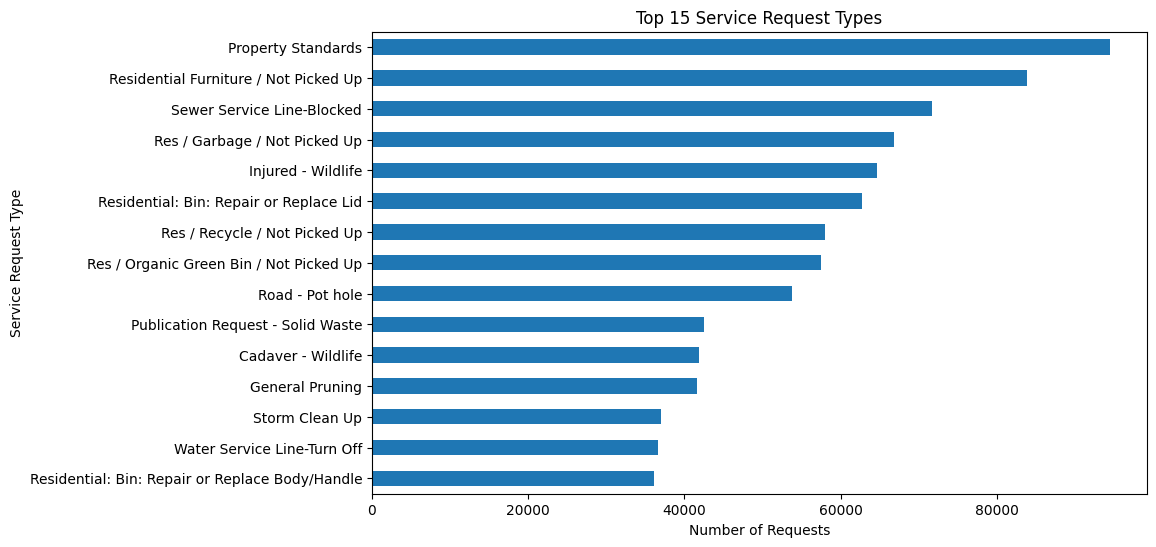

In [102]:
#chart of top 15 service request types

plt.figure(figsize=(10, 6))
top_service_types.sort_values().plot(kind="barh") #kind = barh creates a horizontal bar chart

plt.title("Top 15 Service Request Types")
plt.xlabel("Number of Requests")
plt.ylabel("Service Request Type")

plt.show()

###### The bar chart shows the top 15 Service Request Type categories in the combined dataset. Property Standards has the highest number of requests, followed by Residential Furniture / Nt Picked Up. The chart helps show which categories appear most often in the selected Toronto 311 data. This supports RQ1 because it shows reported demand concentration by service request category. However, this chart combines the early and recent periods, so it does not yet show whether the top categories changed over time. The next step willcompare service request types by period.

In [103]:
top_service_by_period = (
    df.groupby(["Period", "Service Request Type"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Period", "Count"], ascending=[True, False])
)

top_service_by_period.head(30)

,Period,Service Request Type,Count
319,Early Period (2010-2013),Residential Furniture / Not Picked Up,51560
256,Early Period (2010-2013),Property Standards,49259
389,Early Period (2010-2013),Sewer Service Line-Blocked,42613
133,Early Period (2010-2013),General Pruning,34210
272,Early Period (2010-2013),Res / Garbage / Not Picked Up,32568
295,Early Period (2010-2013),Res / Organic Bin / Replace Damaged,32158
423,Early Period (2010-2013),Storm Clean Up,31854
236,Early Period (2010-2013),Operator / Operations Complaint,29339
305,Early Period (2010-2013),Res / Recycle / Not Picked Up,28976
301,Early Period (2010-2013),Res / Organic Green Bin / Not Picked Up,28786


In [104]:
top10_service_by_period = (
    top_service_by_period
    .groupby("Period")
    .head(10)
)

top10_service_by_period

,Period,Service Request Type,Count
319,Early Period (2010-2013),Residential Furniture / Not Picked Up,51560
256,Early Period (2010-2013),Property Standards,49259
389,Early Period (2010-2013),Sewer Service Line-Blocked,42613
133,Early Period (2010-2013),General Pruning,34210
272,Early Period (2010-2013),Res / Garbage / Not Picked Up,32568
295,Early Period (2010-2013),Res / Organic Bin / Replace Damaged,32158
423,Early Period (2010-2013),Storm Clean Up,31854
236,Early Period (2010-2013),Operator / Operations Complaint,29339
305,Early Period (2010-2013),Res / Recycle / Not Picked Up,28976
301,Early Period (2010-2013),Res / Organic Green Bin / Not Picked Up,28786


##### The top 10 Service Request Type table shows that the highest-volume categories changed between the early and recent periods. In the early period, Residential Furniture / Not Picked Up was the most common request type, followed by Property Standards and Sewer Service Line-Blocked. In the recent period, Injured - Wildlife became the highest-volume request type, followed by Residential: Bin: Repair or Replace Lid and Property Standards. This result supports RQ1 because it shows that reported 311 demand concentration by service request type changed across the two comparison periods. Some categories appear in both periods, such as Property Standards, Res / Garbage / Not Picked Up, Residential Furniture / Not Picked Up, Sewer Service Line-Blocked, Res / Recycle / Not Picked Up, and Res / Organic Green Bin / Not Picked Up. However, the ranking and composition of the top categories changed. This should be interpreted as a change in reported 311 patterns, not as proof that actual municipal need changed by the same amount.

In [105]:
# Top 10 service requests in each period
top10_service_by_period = top_service_by_period.groupby("Period").head(10).copy()

period_totals = df["Period"].value_counts()
top10_service_by_period["Period Total"] = top10_service_by_period["Period"].map(period_totals)
top10_service_by_period["Percent of Period"] = (
    top10_service_by_period["Count"] / top10_service_by_period["Period Total"] * 100
).round(2)

top10_service_by_period

,Period,Service Request Type,Count,Period Total,Percent of Period
319,Early Period (2010-2013),Residential Furniture / Not Picked Up,51560,1232720,4.18
256,Early Period (2010-2013),Property Standards,49259,1232720,4.00
389,Early Period (2010-2013),Sewer Service Line-Blocked,42613,1232720,3.46
133,Early Period (2010-2013),General Pruning,34210,1232720,2.78
272,Early Period (2010-2013),Res / Garbage / Not Picked Up,32568,1232720,2.64
295,Early Period (2010-2013),Res / Organic Bin / Replace Damaged,32158,1232720,2.61
423,Early Period (2010-2013),Storm Clean Up,31854,1232720,2.58
236,Early Period (2010-2013),Operator / Operations Complaint,29339,1232720,2.38
305,Early Period (2010-2013),Res / Recycle / Not Picked Up,28976,1232720,2.35
301,Early Period (2010-2013),Res / Organic Green Bin / Not Picked Up,28786,1232720,2.34


##### The top service request types changed between the early and recent periods. In the early period, Residential Furniture / Not Picked Up was the highest-volume request type, making up 4.18% of early-period records. Property Standards was second at 4.00%, followed by Sewer Service Line-Blocked at 3.46%.

##### In the recent period, Injured - Wildlife became the highest-volume request type, making up 3.85% of recent-period records. Residential: Bin: Repair or Replace Lid was second at 3.35%, followed by Property Standards at 2.69%. This result supports RQ1 because it shows that the most common reported 311 request categories did not stay the same across the two comparison periods. Some categories appear in both periods, such as Property Standards, Residential Furniture / Not Picked Up, Res / Garbage / Not Picked Up, Sewer Service Line-Blocked, Res / Recycle / Not Picked Up, and Res / Organic Green Bin / Not Picked Up. However, their rankings and percentage shares changed. These findings should be interpreted as changes in reported 311 patterns, not as proof that actual municipal need changed by the same amount.

In [106]:
#Division counts and Percentaghes
division_summary = pd.DataFrame({
    "Count": df["Division"].value_counts(),
    "Percent": (df["Division"].value_counts() / len(df) * 100).round(2)
})

division_summary

,Count,Percent
Division,,
Solid Waste Management Services,1159083,39.78
Transportation Services,623882,21.41
Municipal Licensing & Standards,602183,20.67
Toronto Water,332530,11.41
Urban Forestry,99007,3.40
311,60219,2.07
Parks,20532,0.70
Unknown,14544,0.50
Parks and Recreation,1437,0.05


##### The Division distribution shows that reported 311 requests are concentrated in a small number of City divisions. Solid Waste Management Services has the highest number of records, with 1,159,083 requests, or 39.78% of the full dataset. Transportation Services is second at 21.41%, followed by Municipal Licensing & Standards at 20.67% and Toronto Water at 11.41%.

#### This result supports RQ1 because it shows that reported 311 demand is not evenly distributed across divisions. Most requests in the selected dataset are connected to Solid Waste Management Services, Transportation Services, Municipal Licensing & Standards, and Toronto Water. Smaller divisions such as Parks, Parks and Recreation, and City of Toronto make up a much smaller share of the open dataset.

In [107]:
#Compare division counts by period

division_by_period = (
    df.groupby(["Period", "Division"])
    .size() # counts # of rows
    .reset_index(name="Count") #makes it into a table
    .sort_values(["Period", "Count"], ascending=[True, False]) #sort period by ascending, count by largest to smallest
)

division_by_period

,Period,Division,Count
3,Early Period (2010-2013),Solid Waste Management Services,550241
5,Early Period (2010-2013),Transportation Services,197045
4,Early Period (2010-2013),Toronto Water,194328
2,Early Period (2010-2013),Municipal Licensing & Standards,161732
6,Early Period (2010-2013),Urban Forestry,99007
0,Early Period (2010-2013),311,30282
1,Early Period (2010-2013),City of Toronto,85
11,Recent Period (2022-2025),Solid Waste Management Services,608842
8,Recent Period (2022-2025),Municipal Licensing & Standards,440451
13,Recent Period (2022-2025),Transportation Services,426837


In [108]:
#Add percentage share within each period for division

period_totals = df["Period"].value_counts()
division_by_period["Period Total"] = division_by_period["Period"].map(period_totals)
division_by_period["Percent of Period"] = (
    division_by_period["Count"] / division_by_period["Period Total"] * 100
).round(2)

division_by_period

,Period,Division,Count,Period Total,Percent of Period
3,Early Period (2010-2013),Solid Waste Management Services,550241,1232720,44.64
5,Early Period (2010-2013),Transportation Services,197045,1232720,15.98
4,Early Period (2010-2013),Toronto Water,194328,1232720,15.76
2,Early Period (2010-2013),Municipal Licensing & Standards,161732,1232720,13.12
6,Early Period (2010-2013),Urban Forestry,99007,1232720,8.03
0,Early Period (2010-2013),311,30282,1232720,2.46
1,Early Period (2010-2013),City of Toronto,85,1232720,0.01
11,Recent Period (2022-2025),Solid Waste Management Services,608842,1680782,36.22
8,Recent Period (2022-2025),Municipal Licensing & Standards,440451,1680782,26.21
13,Recent Period (2022-2025),Transportation Services,426837,1680782,25.40


##### The division comparison shows that Solid Waste Management Services is the largest division in both periods, but its share decreased from 44.64% in the early period to 36.22% in the recent period. Municipal Licensing & Standards increased from 13.12% to 26.21%, and Transportation Services increased from 15.98% to 25.40%. Toronto Water decreased from 15.76% in the early period to 8.22% in the recent period.

##### This supports RQ1 because it shows that reported 311 demand by division changed across the two comparison periods. The results suggest that the recent period has a larger share of requests connected to Municipal Licensing & Standards and Transportation Services, while the early period had a larger share connected to Solid Waste Management Services and Toronto Water. These are reported request patterns only and should not be interpreted as direct proof of actual service need or workload.

# RQ 2

In [109]:
#Compare season counts by period

season_by_period = (
    df.groupby(["Period", "Season"])
    .size()
    .reset_index(name="Count")
)

season_by_period

,Period,Season,Count
0,Early Period (2010-2013),Fall,317402
1,Early Period (2010-2013),Spring,289163
2,Early Period (2010-2013),Summer,372834
3,Early Period (2010-2013),Winter,253321
4,Recent Period (2022-2025),Fall,401017
5,Recent Period (2022-2025),Spring,415075
6,Recent Period (2022-2025),Summer,464595
7,Recent Period (2022-2025),Winter,400095


In [110]:
period_totals = df["Period"].value_counts()

season_by_period["Period Total"] = season_by_period["Period"].map(period_totals)
season_by_period["Percent of Period"] = (
    season_by_period["Count"] / season_by_period["Period Total"] * 100
).round(2)

season_by_period

,Period,Season,Count,Period Total,Percent of Period
0,Early Period (2010-2013),Fall,317402,1232720,25.75
1,Early Period (2010-2013),Spring,289163,1232720,23.46
2,Early Period (2010-2013),Summer,372834,1232720,30.24
3,Early Period (2010-2013),Winter,253321,1232720,20.55
4,Recent Period (2022-2025),Fall,401017,1680782,23.86
5,Recent Period (2022-2025),Spring,415075,1680782,24.70
6,Recent Period (2022-2025),Summer,464595,1680782,27.64
7,Recent Period (2022-2025),Winter,400095,1680782,23.80


##### The season by period comparison shows that seasonal request patterns are fairly similar across the early and recent periods. In both periods, Summer has the highest share of reported 311 requests. Summer made up 30.24% of early-period records and 27.64% of recent-period records. Only off by about ~ 3%.

##### The seasonal shares are generally spread between about 20% and 30% in both periods, which suggests that reported 311 activity occurs throughout the year rather than being concentrated in only one season. Winter increased from 20.55% in the early period to 23.80% in the recent period, while Fall decreased slightly from 25.75% to 23.86%. Spring stayed fairly similar, increasing from 23.46% to 24.70%. This supports RQ2 because it does shows that there are seasonal differences in reported 311 requests, however the overall seasonal distribution is not extremely uneven. So, it is not a strong support for the hypothesis being claimed for RQ2. Nest, I am going to compare requests by month to see whether there are peaks within the seasons.

In [111]:
# Compare month counts by period

month_by_period = (
    df.groupby(["Period", "Month", "Month Name"])
    .size()
    .reset_index(name="Count")
)

month_by_period

,Period,Month,Month Name,Count
0,Early Period (2010-2013),1,January,83674
1,Early Period (2010-2013),2,February,78359
2,Early Period (2010-2013),3,March,88437
3,Early Period (2010-2013),4,April,92644
4,Early Period (2010-2013),5,May,108082
5,Early Period (2010-2013),6,June,123586
6,Early Period (2010-2013),7,July,125109
7,Early Period (2010-2013),8,August,124139
8,Early Period (2010-2013),9,September,115569
9,Early Period (2010-2013),10,October,104884


##### The monthly comparison shows that both periods have higher reported 311 request counts during the warmer months. In the early period, June, July, and August had the highest monthly counts, with July being the highest at 125,109 records. In the recent period, May through August had high counts, with June being the highest at 157,545 records.

##### This supports the earlier season result because Summer had the highest share of requests in both periods. The recent period also shows higher January and February counts compared to the early period, which helps explain why Winter increased from 20.55% of early-period records to 23.80% of recent-period records. These results support RQ2 by showing that reported 311 activity has monthly and seasonal patterns, even though the seasonal distribution is not extremely uneven.

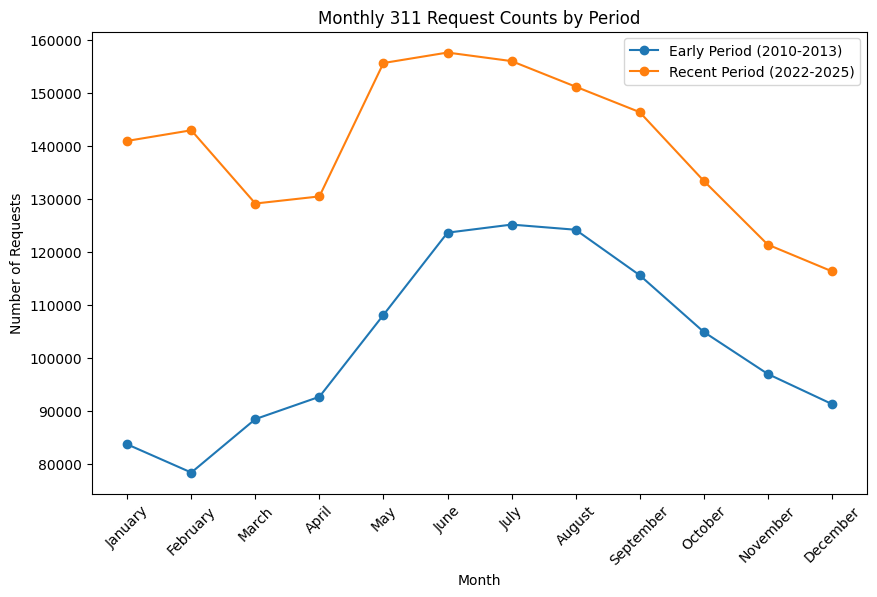

In [112]:
# Plot monthly request counts by period

plt.figure(figsize=(10, 6))

for period in month_by_period["Period"].unique():
    data = month_by_period[month_by_period["Period"] == period]
    plt.plot(data["Month Name"], data["Count"], marker="o", label=period) # "o" - adds a cricle marker ti each data point on the line chart

plt.title("Monthly 311 Request Counts by Period")
plt.xlabel("Month")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45) #labels displayed at 45 degree angle
plt.legend()

plt.show()

##### The monthly line chart shows that the recent period has higher request counts than the early period in every month. This is expected because the recent period has more records overall. More importantly, both periods show a similar seasonal shape. Request counts increase in the spring, stay high during the summer months, and then decline into the fall and winter.

##### In the early period, the highest monthly count appears in July. In the recent period, the highest monthly count appears in June. The recent period also has higher January and February counts compared with the early period, which helps explain why the Winter share increased in the season-by-period table. Overall, this chart supports RQ2 by showing that reported 311 request activity follows monthly and seasonal patterns.

In [113]:
division_pivot = division_by_period.pivot(
    index="Division",
    columns="Period",
    values="Percent of Period"
).fillna(0)

division_pivot

Period,Early Period (2010-2013),Recent Period (2022-2025)
Division,,
311,2.46,1.78
City of Toronto,0.01,0.00
Municipal Licensing & Standards,13.12,26.21
Parks,0.00,1.22
Parks and Recreation,0.00,0.09
Solid Waste Management Services,44.64,36.22
Toronto Water,15.76,8.22
Transportation Services,15.98,25.40
Unknown,0.00,0.87


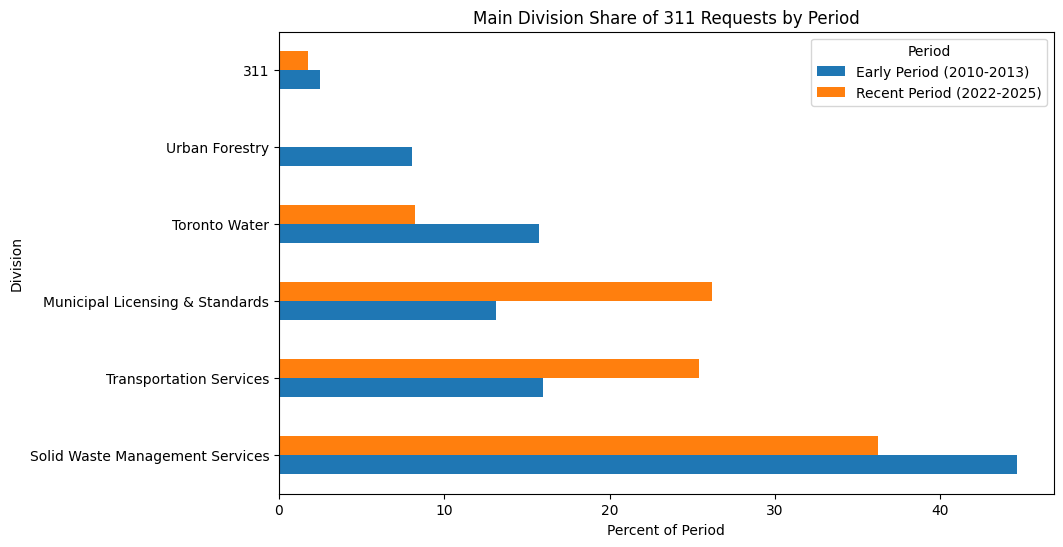

In [114]:
#Plot main division percentage by period

main_divisions = [
    "Solid Waste Management Services",
    "Transportation Services",
    "Municipal Licensing & Standards",
    "Toronto Water",
    "Urban Forestry",
    "311"
]

division_pivot_main = division_pivot.loc[main_divisions]
division_pivot_main.plot(kind="barh", figsize=(10, 6))
plt.title("Main Division Share of 311 Requests by Period")
plt.xlabel("Percent of Period")
plt.ylabel("Division")
plt.legend(title="Period")

plt.show()

##### This chart focuses on the main divisions with the largest shares of reported 311 requests. Solid Waste Management Services remains the largest division in both periods, but its share decreased from 44.64% in the early period to 36.22% in the recent period. Municipal Licensing & Standards increased from 13.12% to 26.21%, and Transportation Services increased from 15.98% to 25.40%. Toronto Water decreased from 15.76% to 8.22%.

##### This supports RQ1 because it shows that reported 311 demand by City division changed between the early and recent periods. I focused the chart on the main divisions because the smaller categories had very low percentages and made the full chart harder to read. The full division table is still included above for transparency.

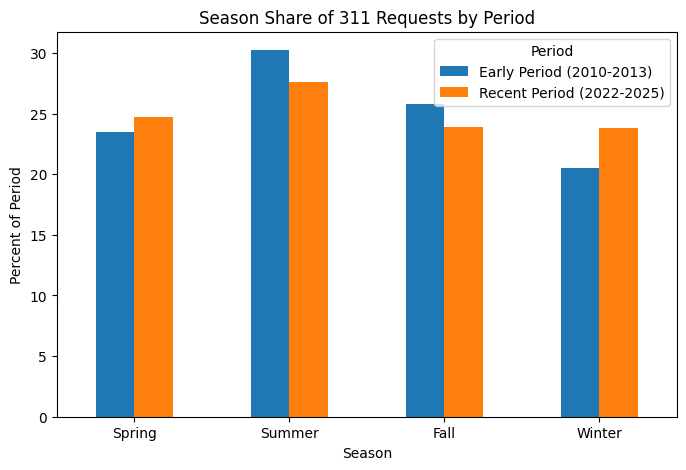

In [115]:
#Plot season percentage by period

season_pivot = season_by_period.pivot(
    index="Season",
    columns="Period",
    values="Percent of Period"
)

season_pivot = season_pivot.reindex(["Spring", "Summer", "Fall", "Winter"])
season_pivot.plot(kind="bar", figsize=(8, 5))
plt.title("Season Share of 311 Requests by Period")
plt.xlabel("Season")
plt.ylabel("Percent of Period")
plt.xticks(rotation=0)
plt.legend(title="Period")

plt.show()

#####The season share chart shows that reported 311 requests are spread across all four seasons in both periods. Summer has the highest share in both the early and recent periods, but the seasonal pattern is not extremely uneven. In the early period, Summer made up 30.24% of requests, while in the recent period it made up 27.64%.

#####Winter increased from 20.55% in the early period to 23.80% in the recent period. Spring also increased slightly, while Fall decreased slightly. This supports RQ2 because it shows that there are seasonal differences in reported 311 request patterns, but the overall seasonal distribution is still fairly balanced.

### Pareto / Cumulative Share Analysis for Service Request Type

This analysis checks how concentrated reported 311 demand is across service request types. Since there are 970 unique service request types, a Pareto-style chart helps show whether a small number of categories account for most requests or whether demand is spread across many categories.

In [116]:
# I really want to know the answer to this, Are most 311 requests coming from only a few service request types, or are requests spread across many different types?
# I'm using the Pareto analysis, "80/20 rule" to find out

service_counts = df["Service Request Type"].value_counts().reset_index()
service_counts.columns = ["Service Request Type", "Count"]
service_counts["Percent"] = (service_counts["Count"] / service_counts["Count"].sum() * 100).round(2)
service_counts["Cumulative Percent"] = service_counts["Percent"].cumsum().round(2) #cumulative sum

service_counts.head(20)

,Service Request Type,Count,Percent,Cumulative Percent
0,Property Standards,94487,3.24,3.24
1,Residential Furniture / Not Picked Up,83812,2.88,6.12
2,Sewer Service Line-Blocked,71653,2.46,8.58
3,Res / Garbage / Not Picked Up,66825,2.29,10.87
4,Injured - Wildlife,64628,2.22,13.09
5,Residential: Bin: Repair or Replace Lid,62759,2.15,15.24
6,Res / Recycle / Not Picked Up,57951,1.99,17.23
7,Res / Organic Green Bin / Not Picked Up,57450,1.97,19.20
8,Road - Pot hole,53816,1.85,21.05
9,Publication Request - Solid Waste,42546,1.46,22.51


##### Pareto / Cumulative Share Result
The Pareto-style table shows that the top 20 Service Request Type categories account for 34.38% of all records. Property Standards is the largest category, but it only represents 3.24% of the full dataset. This means reported 311 demand is not dominated by one single service request type.

This result supports RQ1 because it shows that reported demand is spread across many service request categories. The dataset has 970 unique service request types, so the top categories are important for identifying high-volume requests, but they do not explain the full dataset on their own. This supports the use of rankings, percentage shares, and cumulative shares rather than relying only on raw counts. This is a good sign, the data is not being skewed by one category alone.

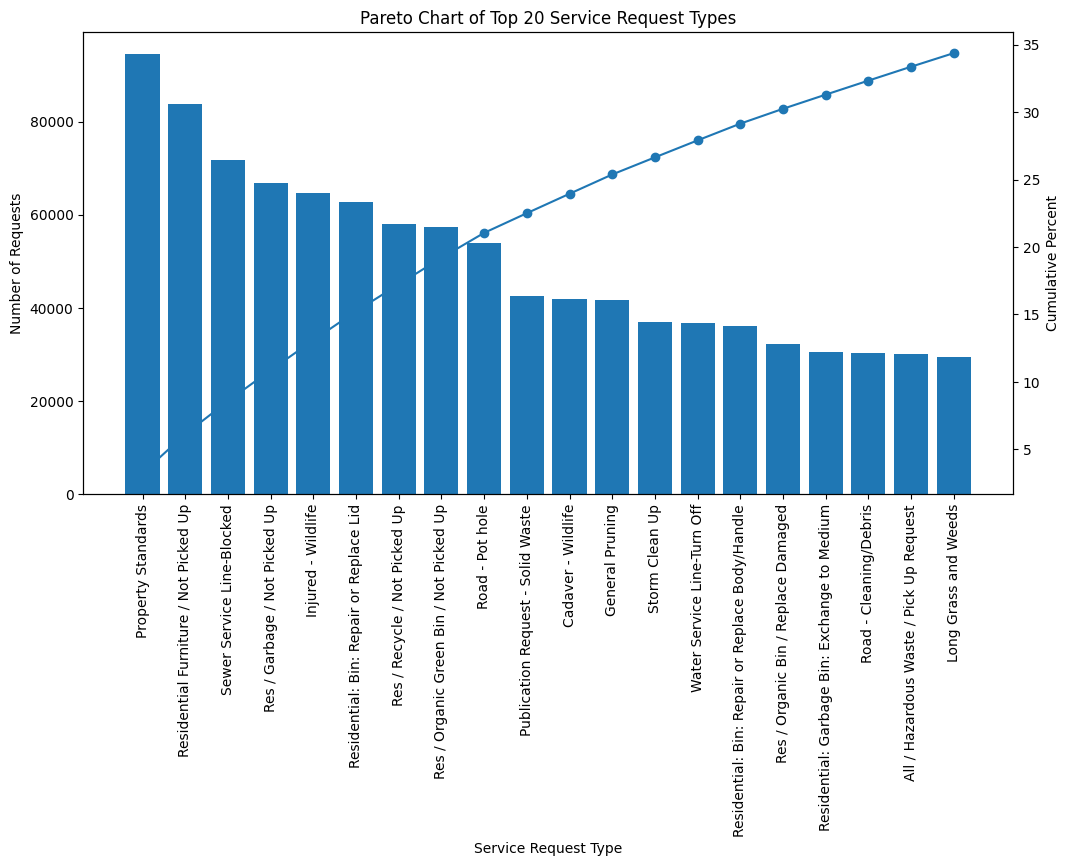

In [117]:
# Plot Pareto-style chart for top 20 service request types

top20_pareto = service_counts.head(20)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(top20_pareto["Service Request Type"], top20_pareto["Count"])
ax1.set_xlabel("Service Request Type")
ax1.set_ylabel("Number of Requests")
ax1.tick_params(axis="x", rotation=90)
ax2 = ax1.twinx()
ax2.plot(top20_pareto["Service Request Type"], top20_pareto["Cumulative Percent"], marker="o")
ax2.set_ylabel("Cumulative Percent")
plt.title("Pareto Chart of Top 20 Service Request Types")
plt.show()

##### The Pareto chart shows the top 20 Service Request Type categories by request count and their cumulative share of the full dataset. Property Standards has the highest count, but the cumulative line shows that the top 20 categories together only account for about 34.38% of all records. This means reported 311 demand is spread across many service request categories rather than being concentrated in only a few. This supports RQ1 because it shows why both rankings and percentage shares are needed when comparing early and recent demand patterns. It also supports the decision to focus on high-volume categories for interpretation while recognizing that the dataset contains a much wider range of request types.

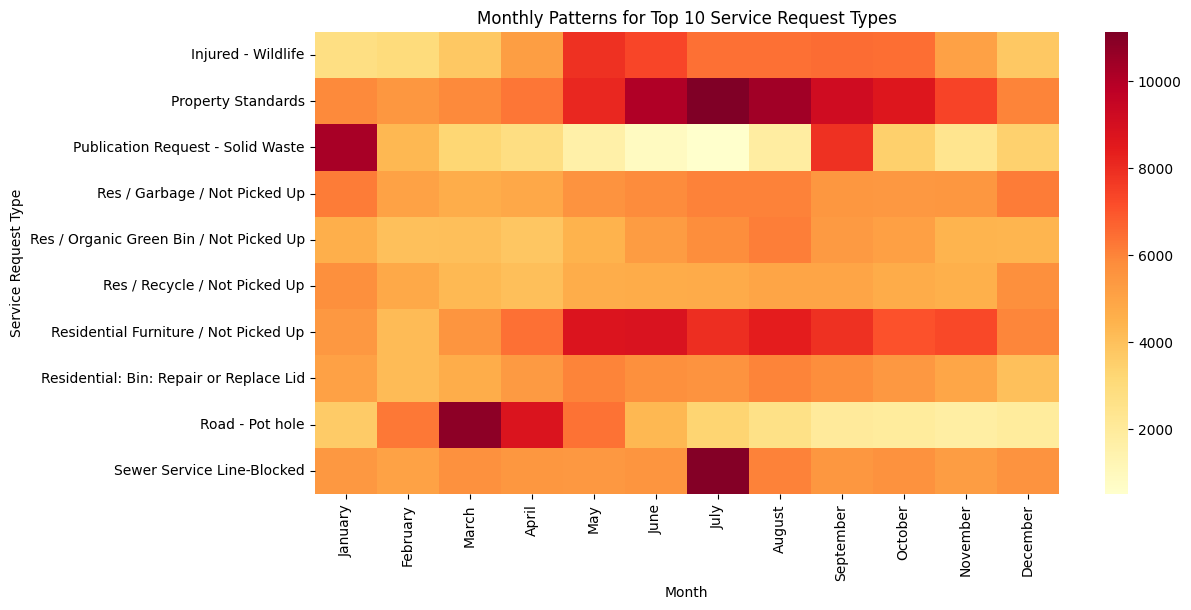

In [118]:
#Heatmap for top 10 service request types over both periods

top10_service_types = df["Service Request Type"].value_counts().head(10).index

heatmap_data = (
    df[df["Service Request Type"].isin(top10_service_types)]
    .groupby(["Service Request Type", "Month Name"])
    .size()
    .reset_index(name="Count")
)

heatmap_pivot = heatmap_data.pivot(
    index="Service Request Type",
    columns="Month Name",
    values="Count"
).fillna(0)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

heatmap_pivot = heatmap_pivot[month_order]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_pivot, annot=False, cmap="YlOrRd") # i want it to be pink
plt.title("Monthly Patterns for Top 10 Service Request Types")
plt.xlabel("Month")
plt.ylabel("Service Request Type")

plt.show()

### Heatmap

##### The heatmap shows monthly patterns for the top 10 Service Request Type categories. Darker colours represent months with higher request counts. The chart shows that high-volume request types do not all follow the same monthly pattern.

##### Property Standards and Residential Furniture / Not Picked Up show higher activity in the warmer months. Road - Pot hole has a clear increase around March and April, which may reflect road conditions after winter. Injured - Wildlife is also higher in the warmer months, especially from May to October. Publication Request - Solid Waste has a noticeable spike in January and another high point around September.

##### This supports RQ2 because it shows that monthly and seasonal patterns vary by service request type. The overall monthly trend is useful, but this heatmap shows that different categories have their own timing patterns. These results should still be interpreted as reported 311 activity, not as proof of actual service conditions.

## Baseline Model

This section builds one simple baseline model connected to RQ2. The goal is to test whether past monthly request patterns can provide a basic prediction of recent monthly request volume. The model uses 2022–2024 monthly request counts as training data and predicts 2025 monthly request counts. This avoids leakage because the 2025 test data is not used to create the baseline predictions.

In [119]:
# Create monthly request counts by year and month

monthly_counts = (
    df.groupby(["Year", "Month", "Month Name"])
    .size()
    .reset_index(name="Actual Count")
    .sort_values(["Year", "Month"])
)

monthly_counts

,Year,Month,Month Name,Actual Count
0,2010,1,January,15177
1,2010,2,February,13918
2,2010,3,March,19274
3,2010,4,April,20092
4,2010,5,May,20336
5,2010,6,June,29534
6,2010,7,July,26681
7,2010,8,August,26711
8,2010,9,September,23540
9,2010,10,October,21342


In [120]:
# Create training data using 2022 to 2024

train_monthly = monthly_counts[monthly_counts["Year"].isin([2022, 2023, 2024])]

train_monthly

,Year,Month,Month Name,Actual Count
48,2022,1,January,44392
49,2022,2,February,35605
50,2022,3,March,30831
51,2022,4,April,30208
52,2022,5,May,35387
53,2022,6,June,41964
54,2022,7,July,36067
55,2022,8,August,39954
56,2022,9,September,36744
57,2022,10,October,34549


In [121]:
# Create baseline predictions by averaging each month from 2022 to 2024
baseline_predictions = (
    train_monthly
    .groupby(["Month", "Month Name"])["Actual Count"]
    .mean()
    .reset_index(name="Predicted Count")
)

baseline_predictions["Predicted Count"] = baseline_predictions["Predicted Count"].round(0)

baseline_predictions

,Month,Month Name,Predicted Count
0,1,January,36276.0
1,2,February,29875.0
2,3,March,31107.0
3,4,April,31751.0
4,5,May,38423.0
5,6,June,38842.0
6,7,July,37970.0
7,8,August,37334.0
8,9,September,35231.0
9,10,October,32774.0


In [122]:
#Test data using 2025 counts
test_2025 = monthly_counts[monthly_counts["Year"] == 2025].copy()
test_2025

,Year,Month,Month Name,Actual Count
84,2025,1,January,32060
85,2025,2,February,53268
86,2025,3,March,35761
87,2025,4,April,35170
88,2025,5,May,40304
89,2025,6,June,41020
90,2025,7,July,42023
91,2025,8,August,39113
92,2025,9,September,40624
93,2025,10,October,35042


In [123]:
# Compare actual 2025 counts with baseline predictions
baseline_results = pd.merge(
    test_2025,
    baseline_predictions,
    on=["Month", "Month Name"]
)

baseline_results

,Year,Month,Month Name,Actual Count,Predicted Count
0,2025,1,January,32060,36276.0
1,2025,2,February,53268,29875.0
2,2025,3,March,35761,31107.0
3,2025,4,April,35170,31751.0
4,2025,5,May,40304,38423.0
5,2025,6,June,41020,38842.0
6,2025,7,July,42023,37970.0
7,2025,8,August,39113,37334.0
8,2025,9,September,40624,35231.0
9,2025,10,October,35042,32774.0


In [124]:
# Calculate prediction errors

baseline_results["Error"] = baseline_results["Actual Count"] - baseline_results["Predicted Count"]
baseline_results["Absolute Error"] = baseline_results["Error"].abs()
baseline_results["Percent Error"] = (
    baseline_results["Absolute Error"] / baseline_results["Actual Count"] * 100
).round(2)
baseline_results

,Year,Month,Month Name,Actual Count,Predicted Count,Error,Absolute Error,Percent Error
0,2025,1,January,32060,36276.0,-4216.0,4216.0,13.15
1,2025,2,February,53268,29875.0,23393.0,23393.0,43.92
2,2025,3,March,35761,31107.0,4654.0,4654.0,13.01
3,2025,4,April,35170,31751.0,3419.0,3419.0,9.72
4,2025,5,May,40304,38423.0,1881.0,1881.0,4.67
5,2025,6,June,41020,38842.0,2178.0,2178.0,5.31
6,2025,7,July,42023,37970.0,4053.0,4053.0,9.64
7,2025,8,August,39113,37334.0,1779.0,1779.0,4.55
8,2025,9,September,40624,35231.0,5393.0,5393.0,13.28
9,2025,10,October,35042,32774.0,2268.0,2268.0,6.47


#####The baseline model compares actual 2025 monthly request counts against predictions created from the average monthly counts in 2022, 2023, and 2024. The model performs better in some months, such as May, June, August, October, and November, where the percent error is relatively low. However, the model performs worse in February and December, where the actual 2025 counts are much higher than the baseline prediction.

##### This shows that a simple monthly average can capture some of the regular monthly pattern, but it does not fully account for unusual spikes or changes in reporting volume. This connects to RQ2 because the model is based on monthly request patterns and shows where those patterns are more or less stable.

In [125]:
# Calculate baseline model evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    baseline_results["Actual Count"],
    baseline_results["Predicted Count"]
)
rmse = np.sqrt(
    mean_squared_error(
        baseline_results["Actual Count"],
        baseline_results["Predicted Count"]
    )
)
mape = baseline_results["Percent Error"].mean()
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("Mean Absolute Percentage Error (MAPE):", round(mape, 2), "%")

Mean Absolute Error (MAE): 5578.75
Root Mean Squared Error (RMSE): 8201.21
Mean Absolute Percentage Error (MAPE): 13.39 %


##### The baseline model was evaluated by comparing the predicted 2025 monthly request counts with the actual 2025 monthly request counts. The Mean Absolute Error (MAE) was 5,578.75, meaning the model was off by about 5,579 requests per month on average. The Root Mean Squared Error (RMSE) was 8,201.21, which is higher than the MAE because some months had larger errors. This matches the month-by-month error table, where February and December had the largest prediction errors.

##### The Mean Absolute Percentage Error (MAPE) was 13.39%, meaning the baseline predictions were off by about 13.39% on average. For a simple monthly average baseline, this gives a useful starting point. The model captures some regular monthly patterns, but it does not fully explain unusual spikes or changes in reporting volume. This supports RQ2 because it shows that monthly request patterns are somewhat predictable, but still uncertain.

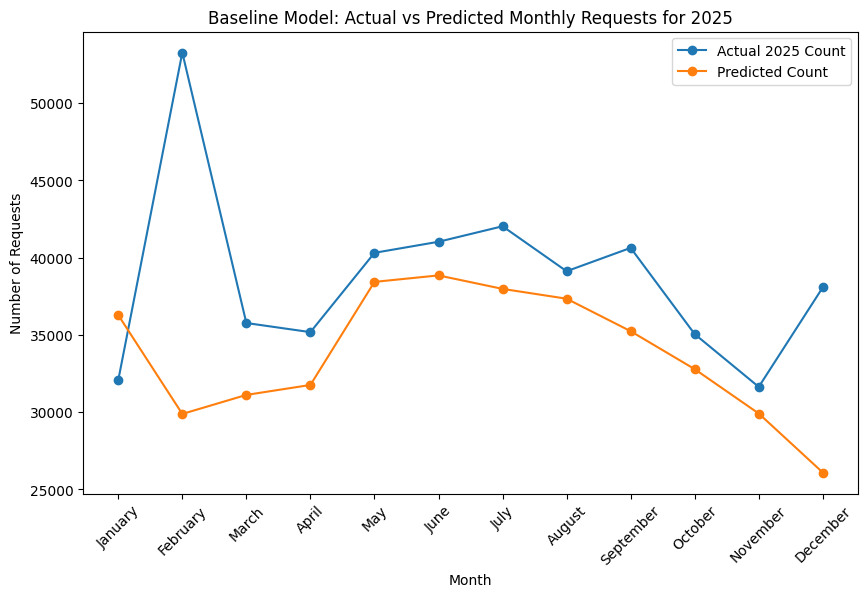

In [126]:
# Plot actual vs predicted monthly request counts for 2025

plt.figure(figsize=(10, 6))
plt.plot(
    baseline_results["Month Name"],
    baseline_results["Actual Count"],
    marker="o",
    label="Actual 2025 Count"
)

plt.plot(
    baseline_results["Month Name"],
    baseline_results["Predicted Count"],
    marker="o",
    label="Predicted Count"
)

plt.title("Baseline Model: Actual vs Predicted Monthly Requests for 2025")
plt.xlabel("Month")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### The actual versus predicted chart shows how the baseline model performed across each month of 2025. The predicted line follows the general monthly pattern in some parts of the year, especially from May to November, where the gap between the actual and predicted values is smaller.
##### However, the model misses larger spikes in February and December. February 2025 had the largest difference between actual and predicted values, which increased the overall RMSE. This shows that the baseline model can provide a basic monthly expectation, but it does not fully capture unusual changes or spikes in reported 311 activity.
##### Overall, the baseline model is useful as a simple comparison point, but it should not be treated as a final predictive model. The results show that monthly patterns are somewhat stable, but there is still uncertainty in future request volume.

## Summary of Key Findings

### Data Quality Summary

The combined dataset contains 2,913,502 records across the selected years. The main fields used for analysis, including Creation Date, Status, Ward, Service Request Type, Division, Section, Source Year, and Period, had no missing values. The two intersection street fields had high missingness, with Intersection Street 1 missing 87.50% of values and Intersection Street 2 missing 87.56% of values. Because of this, the intersection fields were not used as primary analysis fields.

The duplicate check found 2,318 duplicate rows, which represents about 0.08% of the full dataset. Since the dataset does not include a unique service request ID, these duplicates were documented as a data quality issue but not treated as a major limitation for the period-level analysis.

### EDA Summary

The EDA showed that reported 311 demand increased from 1,232,720 records in the early period to 1,680,782 records in the recent period. The top service request categories changed across the two periods. In the early period, Residential Furniture / Not Picked Up and Property Standards were the highest-volume categories. In the recent period, Injured - Wildlife became the highest-volume category, followed by Residential: Bin: Repair or Replace Lid and Property Standards.

The division-level results also changed by period. Solid Waste Management Services remained the largest division in both periods, but its share decreased from 44.64% in the early period to 36.22% in the recent period. Municipal Licensing & Standards and Transportation Services had larger shares in the recent period compared with the early period.

The seasonal and monthly analysis showed that request volume is generally higher in the warmer months, especially spring and summer. However, the heatmap showed that different service request types have different monthly patterns. This supports the idea that seasonality is not the same across all 311 request categories.

### Pareto and Heatmap Summary

The Pareto analysis showed that the top 20 service request types account for 34.38% of all records. This means 311 demand is not concentrated in only a few categories. Instead, reported demand is spread across many service request types.

The heatmap of the top 10 service request types showed different monthly patterns across categories. For example, Road - Pot hole had higher activity around March and April, while Property Standards and Injured - Wildlife were higher in warmer months. This supports RQ2 because it shows that monthly patterns vary depending on the type of request.